# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pathakadithi/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [29]:
!git clone https://github.com/pathakadithi/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 233, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (182/182), done.
remote: Total 233 (delta 116), reused 96 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (233/233), 2.04 MiB | 9.93 MiB/s, done.
Resolving deltas: 100% (116/116), done.


In [30]:
%cd flyrank-ml-internship
!find work -maxdepth 3 -type f | sort

/content/flyrank-ml-internship/flyrank-ml-internship
work/capstone_report_template.md
work/notebooks/capstone.ipynb
work/notebooks/w01_research_question.ipynb
work/notebooks/w02_ml_task_framing.ipynb
work/notebooks/w03_data_contract.ipynb
work/notebooks/w03_feature_leakage_check.ipynb
work/notebooks/w04_baseline_score.ipynb
work/notebooks/w04_signal_audit.ipynb
work/notebooks/w05_model.ipynb
work/notebooks/w06_validation_audit.ipynb
work/notebooks/w07_action_playbook.ipynb
work/README.md
work/work/capstone_report.md


In [31]:
from pathlib import Path

print("Repository:", Path.cwd())

print("\nCSV files:")
for p in Path("work").rglob("*.csv"):
    print(p)

print("\nJSON files:")
for p in Path("work").rglob("*.json"):
    print(p)

print("\nNotebook files:")
for p in Path("work").rglob("*.ipynb"):
    print(p)

Repository: /content/flyrank-ml-internship/flyrank-ml-internship

CSV files:

JSON files:

Notebook files:
work/notebooks/w01_research_question.ipynb
work/notebooks/w04_baseline_score.ipynb
work/notebooks/w02_ml_task_framing.ipynb
work/notebooks/w06_validation_audit.ipynb
work/notebooks/w04_signal_audit.ipynb
work/notebooks/w07_action_playbook.ipynb
work/notebooks/w03_feature_leakage_check.ipynb
work/notebooks/capstone.ipynb
work/notebooks/w03_data_contract.ipynb
work/notebooks/w05_model.ipynb


In [32]:
import json
from pathlib import Path

notebook_path = Path("work/notebooks/w05_model.ipynb")

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    print(f"\n{'='*80}")
    print(f"CELL {i} — {cell['cell_type']}")
    print(f"{'='*80}")
    print("".join(cell["source"]))


CELL 0 — markdown
# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pathakadithi/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

CELL 1 — markdown
## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

CELL 2 — code
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


CELL 3 — markdown
### Method choice

I chose **Logistic Regression** because my lane is Refresh / Content Opportunity Scoring, where the goal is to predict whether a page is a refresh opportunity.

Logistic 

In [33]:
# ML-10 — Section 1: Recreate the validated model and generate an action queue

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 1. Load the same warehouse table used in W05
# ------------------------------------------------------------

dataset = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_query_90d"
)

df = dataset["train"].to_pandas()

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 2414248
Columns: ['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


In [34]:
# ------------------------------------------------------------
# 2. Recreate W05 features and W04 baseline target
# ------------------------------------------------------------

# CTR features
df["ctr_90d"] = np.where(
    df["impressions_90d"] > 0,
    df["clicks_90d"] / df["impressions_90d"],
    0
)

df["ctr_last30"] = np.where(
    df["impressions_last30"] > 0,
    df["clicks_last30"] / df["impressions_last30"],
    0
)

df["ctr_prev30"] = np.where(
    df["impressions_prev30"] > 0,
    df["clicks_prev30"] / df["impressions_prev30"],
    0
)

# W04 position buckets
df["position_bucket"] = pd.cut(
    df["avg_position_90d"],
    bins=[0, 3, 10, 20, np.inf],
    labels=["1-3", "4-10", "11-20", "21+"],
    include_lowest=True
)

position_ctr = (
    df.groupby("position_bucket", observed=False)["ctr_90d"]
    .mean()
)

df["expected_ctr"] = (
    df["position_bucket"]
    .map(position_ctr)
    .astype(float)
)

df["ctr_gap"] = (
    df["expected_ctr"] - df["ctr_90d"]
).fillna(0)

df["recent_ctr_decline"] = (
    df["ctr_prev30"] - df["ctr_last30"]
).fillna(0)

ctr_gap_scale = df["ctr_gap"].quantile(0.95)
decline_scale = df["recent_ctr_decline"].quantile(0.95)

df["ctr_gap_score"] = (
    df["ctr_gap"] / ctr_gap_scale
).clip(0, 1)

df["decline_score"] = (
    df["recent_ctr_decline"] / decline_scale
).clip(0, 1)

df["baseline_score"] = (
    0.5 * df["ctr_gap_score"]
    + 0.5 * df["decline_score"]
)

df["baseline_action"] = (
    df["baseline_score"] > 0
).astype(int)

print("Baseline target distribution:")
print(df["baseline_action"].value_counts(normalize=True))

Baseline target distribution:
baseline_action
0    0.96243
1    0.03757
Name: proportion, dtype: float64


In [35]:
# ------------------------------------------------------------
# 3. Train the same Logistic Regression used in W05
# ------------------------------------------------------------

features = [
    "impressions_90d",
    "clicks_90d",
    "ctr_90d",
    "avg_position_90d",
    "avg_position_last30"
]

X = df[features]
y = df["baseline_action"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model trained successfully.")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Model trained successfully.
Training rows: 1931398
Test rows: 482850


In [36]:
# ------------------------------------------------------------
# 4. Score all pages for prioritization
# ------------------------------------------------------------

df["opportunity_probability"] = model.predict_proba(
    df[features]
)[:, 1]

# Higher probability = higher review priority
queue = df.sort_values(
    "opportunity_probability",
    ascending=False
).copy()

queue["priority_rank"] = np.arange(1, len(queue) + 1)

print("Queue created:", queue.shape)
print(
    queue[
        [
            "priority_rank",
            "opportunity_probability",
            "baseline_score"
        ]
    ].head(10)
)

Queue created: (2414248, 34)
         priority_rank  opportunity_probability  baseline_score
849395               1                      1.0        0.500000
2414148              2                      1.0        0.500000
1352687              3                      1.0        0.000000
1352681              4                      1.0        0.000000
1352673              5                      1.0        0.500000
848583               6                      1.0        0.000000
1352670              7                      1.0        0.000000
1352569              8                      1.0        0.537429
1455866              9                      1.0        0.000000
1173668             10                      1.0        0.535813


In [37]:
# ------------------------------------------------------------
# 5. Create human-readable reason codes
# ------------------------------------------------------------

def assign_reason(row):
    reasons = []

    if row["ctr_gap"] > 0:
        reasons.append("LOW_CTR_VS_POSITION")

    if row["recent_ctr_decline"] > 0:
        reasons.append("RECENT_CTR_DECLINE")

    if row["avg_position_90d"] > 10:
        reasons.append("LOW_RANKING_POSITION")

    if not reasons:
        reasons.append("MODEL_PRIORITY")

    return "|".join(reasons)


queue["reason_code"] = queue.apply(assign_reason, axis=1)

queue["recommended_action"] = np.where(
    queue["reason_code"].str.contains("RECENT_CTR_DECLINE"),
    "Review for content refresh",
    "Review content opportunity"
)

queue["review_note"] = (
    "Human review required before any content change."
)

print(
    queue[
        [
            "priority_rank",
            "opportunity_probability",
            "recommended_action",
            "reason_code",
            "review_note"
        ]
    ].head(10).to_string(index=False)
)

 priority_rank  opportunity_probability         recommended_action                            reason_code                                      review_note
             1                      1.0 Review for content refresh                     RECENT_CTR_DECLINE Human review required before any content change.
             2                      1.0 Review for content refresh                     RECENT_CTR_DECLINE Human review required before any content change.
             3                      1.0 Review content opportunity                         MODEL_PRIORITY Human review required before any content change.
             4                      1.0 Review content opportunity                         MODEL_PRIORITY Human review required before any content change.
             5                      1.0 Review for content refresh                     RECENT_CTR_DECLINE Human review required before any content change.
             6                      1.0 Review content opportunity    

In [38]:
print("Opportunity probability distribution:")
print(queue["opportunity_probability"].describe())

print("\nNumber of unique probability values:")
print(queue["opportunity_probability"].nunique())

print("\nTop probability values:")
print(queue["opportunity_probability"].value_counts().head(20))

Opportunity probability distribution:
count    2.414248e+06
mean     1.159190e-01
std      2.417108e-01
min      2.529994e-06
25%      3.307604e-02
50%      5.015582e-02
75%      5.666001e-02
max      1.000000e+00
Name: opportunity_probability, dtype: float64

Number of unique probability values:
1640761

Top probability values:
opportunity_probability
0.058083    9051
0.058124    7107
0.058165    5718
1.000000    5619
0.058206    4482
0.058247    3796
0.058288    3073
0.058330    2569
0.059568    2239
0.055826    2189
0.058371    2138
0.058412    1820
0.059610    1758
0.055866    1621
0.058453    1569
0.059651    1546
0.058494    1333
0.056967    1324
0.055905    1293
0.059693    1212
Name: count, dtype: int64


In [39]:
# ------------------------------------------------------------
# 6. Create the paper-ready ranked queue
# ------------------------------------------------------------

queue_export = queue[
    [
        "priority_rank",
        "opportunity_probability",
        "recommended_action",
        "reason_code",
        "review_note",
        "baseline_score",
        "ctr_90d",
        "ctr_last30",
        "ctr_prev30",
        "avg_position_90d",
        "avg_position_last30",
        "impressions_90d",
        "clicks_90d"
    ]
].copy()

print("Export queue shape:", queue_export.shape)
queue_export.head(20)

Export queue shape: (2414248, 13)


,priority_rank,opportunity_probability,recommended_action,reason_code,review_note,baseline_score,ctr_90d,ctr_last30,ctr_prev30,avg_position_90d,avg_position_last30,impressions_90d,clicks_90d
849395,1,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.005160,0.003127,0.011091,5.945820,6.563722,1938,10
2414148,2,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.002944,0.000000,0.002066,5.414236,11.576923,3737,11
1352687,3,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.012383,0.012195,0.010626,0.879550,0.895787,2665,33
1352681,4,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.004913,0.003687,0.003429,2.287861,2.433180,3460,17
1352673,5,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.005030,0.003995,0.006186,1.402414,1.826897,1988,10
848583,6,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.024155,0.031915,0.027027,2.253623,2.675532,414,10
1352670,7,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.013464,0.015180,0.007194,0.874541,0.908918,1634,22
1352569,8,1.0,Review for content refresh,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Human review required before any content change.,0.537429,0.003881,0.001218,0.002650,1.185640,1.565164,3092,12
1455866,9,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.013857,0.033058,0.032468,2.198614,1.454545,866,12
1173668,10,1.0,Review for content refresh,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Human review required before any content change.,0.535813,0.003895,0.002765,0.003336,2.570701,2.715207,3338,13


In [40]:
# ------------------------------------------------------------
# 7. Export queue for the paper
# ------------------------------------------------------------

from pathlib import Path

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "refresh_queue_sample.csv"

queue_export.head(1000).to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")
print(f"Rows exported: {len(queue_export.head(1000))}")

Saved: work/outputs/refresh_queue_sample.csv
Rows exported: 1000


In [41]:
# Top 20 ranked actions
queue_export.head(20)

,priority_rank,opportunity_probability,recommended_action,reason_code,review_note,baseline_score,ctr_90d,ctr_last30,ctr_prev30,avg_position_90d,avg_position_last30,impressions_90d,clicks_90d
849395,1,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.005160,0.003127,0.011091,5.945820,6.563722,1938,10
2414148,2,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.002944,0.000000,0.002066,5.414236,11.576923,3737,11
1352687,3,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.012383,0.012195,0.010626,0.879550,0.895787,2665,33
1352681,4,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.004913,0.003687,0.003429,2.287861,2.433180,3460,17
1352673,5,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.005030,0.003995,0.006186,1.402414,1.826897,1988,10
848583,6,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.024155,0.031915,0.027027,2.253623,2.675532,414,10
1352670,7,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.013464,0.015180,0.007194,0.874541,0.908918,1634,22
1352569,8,1.0,Review for content refresh,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Human review required before any content change.,0.537429,0.003881,0.001218,0.002650,1.185640,1.565164,3092,12
1455866,9,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.013857,0.033058,0.032468,2.198614,1.454545,866,12
1173668,10,1.0,Review for content refresh,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Human review required before any content change.,0.535813,0.003895,0.002765,0.003336,2.570701,2.715207,3338,13


### Archetype → action mapping

The ranked queue is grouped into simple content-opportunity archetypes based on observable signals.

- Recent CTR decline → Review recent title, description, search intent, and content freshness.
- Low CTR versus position → Review the search snippet and alignment with query intent.
- Low ranking position → Review content relevance, completeness, and improvement opportunities.
- Multiple signals → Give higher review attention because more than one signal indicates an opportunity.
- Model priority only → Review the available evidence before deciding whether a refresh is justified.

These mappings are review prompts, not automatic prescriptions. The model does not establish that a specific content change will improve performance.

In [42]:
# Archetype -> action mapping

def assign_archetype(reason_code):
    if "LOW_CTR_VS_POSITION" in reason_code and "RECENT_CTR_DECLINE" in reason_code:
        return "Multiple signals"
    elif "RECENT_CTR_DECLINE" in reason_code:
        return "Recent CTR decline"
    elif "LOW_CTR_VS_POSITION" in reason_code:
        return "Low CTR versus position"
    elif "LOW_RANKING_POSITION" in reason_code:
        return "Low ranking position"
    else:
        return "Model priority only"


def assign_action(archetype):
    mapping = {
        "Recent CTR decline":
            "Review recent title, description, search intent, and content freshness.",
        "Low CTR versus position":
            "Review search snippet and alignment with query intent.",
        "Low ranking position":
            "Review content relevance, completeness, and improvement opportunities.",
        "Multiple signals":
            "Prioritize human review using all available signals.",
        "Model priority only":
            "Inspect available evidence before deciding whether a refresh is justified."
    }
    return mapping[archetype]


queue_export["archetype"] = queue_export["reason_code"].apply(assign_archetype)
queue_export["review_action"] = queue_export["archetype"].apply(assign_action)

queue_export.head(10)

,priority_rank,opportunity_probability,recommended_action,reason_code,review_note,baseline_score,ctr_90d,ctr_last30,ctr_prev30,avg_position_90d,avg_position_last30,impressions_90d,clicks_90d,archetype,review_action
849395,1,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.005160,0.003127,0.011091,5.945820,6.563722,1938,10,Recent CTR decline,"Review recent title, description, search inten..."
2414148,2,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.002944,0.000000,0.002066,5.414236,11.576923,3737,11,Recent CTR decline,"Review recent title, description, search inten..."
1352687,3,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.012383,0.012195,0.010626,0.879550,0.895787,2665,33,Model priority only,Inspect available evidence before deciding whe...
1352681,4,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.004913,0.003687,0.003429,2.287861,2.433180,3460,17,Model priority only,Inspect available evidence before deciding whe...
1352673,5,1.0,Review for content refresh,RECENT_CTR_DECLINE,Human review required before any content change.,0.500000,0.005030,0.003995,0.006186,1.402414,1.826897,1988,10,Recent CTR decline,"Review recent title, description, search inten..."
848583,6,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.024155,0.031915,0.027027,2.253623,2.675532,414,10,Model priority only,Inspect available evidence before deciding whe...
1352670,7,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.013464,0.015180,0.007194,0.874541,0.908918,1634,22,Model priority only,Inspect available evidence before deciding whe...
1352569,8,1.0,Review for content refresh,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Human review required before any content change.,0.537429,0.003881,0.001218,0.002650,1.185640,1.565164,3092,12,Multiple signals,Prioritize human review using all available si...
1455866,9,1.0,Review content opportunity,MODEL_PRIORITY,Human review required before any content change.,0.000000,0.013857,0.033058,0.032468,2.198614,1.454545,866,12,Model priority only,Inspect available evidence before deciding whe...
1173668,10,1.0,Review for content refresh,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Human review required before any content change.,0.535813,0.003895,0.002765,0.003336,2.570701,2.715207,3338,13,Multiple signals,Prioritize human review using all available si...


In [43]:
queue_export.head(1000).to_csv(
    "work/outputs/refresh_queue_sample.csv",
    index=False
)

print("Updated queue exported successfully.")

Updated queue exported successfully.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is intended to help content teams **prioritize pages for human review**. The ranked queue identifies pages that resemble the refresh-opportunity pattern used in the validated W04 baseline, using the Logistic Regression model as a prioritization aid.

The output is intended for research and decision support, not production automation. A high opportunity probability means that a page is worth reviewing earlier; it does not mean that a refresh will definitely improve clicks, CTR, rankings, or traffic.

### Limits

The target is derived from the W04 rule-based baseline, so the model learns to identify patterns in that baseline rather than directly predicting future business outcomes.

The validation results also show that precision is much lower than recall. Under the client-grouped validation, the model achieved approximately **95.22% accuracy, 43.84% precision, 99.96% recall, and 0.609 F1**. This means the queue can surface many potential opportunities, but a substantial number of candidates may not be useful refresh opportunities after human review.

The model should also not be interpreted as causal evidence. The observed signals do not prove that changing a page will cause better performance.

Results may change when the content mix, clients, search behavior, data quality, or time period changes. For these reasons, the queue should be reviewed by a person before any content decision is made.

In [44]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Summary of the exported decision-support queue

print("Queue rows:", len(queue_export))

print("\nOpportunity probability summary:")
print(queue_export["opportunity_probability"].describe())

print("\nArchetype counts:")
print(queue_export["archetype"].value_counts())

print("\nRecommended action counts:")
print(queue_export["recommended_action"].value_counts())

Queue rows: 2414248

Opportunity probability summary:
count    2.414248e+06
mean     1.159190e-01
std      2.417108e-01
min      2.529994e-06
25%      3.307604e-02
50%      5.015582e-02
75%      5.666001e-02
max      1.000000e+00
Name: opportunity_probability, dtype: float64

Archetype counts:
archetype
Low CTR versus position    2223575
Model priority only          91273
Recent CTR decline           74155
Low ranking position         15988
Multiple signals              9257
Name: count, dtype: int64

Recommended action counts:
recommended_action
Review content opportunity    2330836
Review for content refresh      83412
Name: count, dtype: int64


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

Every ranked recommendation must be reviewed by a person before any content change is made.

The reviewer should:

1. Confirm that the page and its data are still relevant.
2. Check the recent CTR and ranking signals.
3. Review the search intent and whether the page satisfies that intent.
4. Check whether the page is already current, accurate, and complete.
5. Consider business importance and the potential value of spending effort on the page.
6. Decide whether a refresh is justified, needs further investigation, or should be skipped.
7. Record the final decision and the reason for accepting or rejecting the recommendation.

The model score should be treated as a prioritization signal only. A reviewer can override the model whenever the page context provides evidence that the recommendation is not appropriate.

### No-go cases

The system should **not automatically**:

- publish or rewrite content;
- change titles, descriptions, headings, or other page elements;
- delete or redirect pages;
- make SEO or business decisions solely from the model score;
- assume that a high score guarantees future traffic, clicks, CTR, or ranking improvement;
- act on a recommendation when the underlying data is missing, stale, or clearly inconsistent;
- prioritize a page only because its model probability is high when human review finds no meaningful content opportunity.

The model is therefore a review-prioritization tool, not an autonomous content management system.

In [45]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Human-review status for every exported recommendation

queue_export["review_status"] = "REQUIRES_HUMAN_REVIEW"

print("Review status:")
print(queue_export["review_status"].value_counts())

print("\nNo automatic content changes are performed by this notebook.")

Review status:
review_status
REQUIRES_HUMAN_REVIEW    2414248
Name: count, dtype: int64

No automatic content changes are performed by this notebook.


In [46]:
# Example human-review queue

review_queue = queue_export[
    [
        "priority_rank",
        "opportunity_probability",
        "archetype",
        "reason_code",
        "review_action",
        "review_status"
    ]
].head(20)

review_queue

,priority_rank,opportunity_probability,archetype,reason_code,review_action,review_status
849395,1,1.0,Recent CTR decline,RECENT_CTR_DECLINE,"Review recent title, description, search inten...",REQUIRES_HUMAN_REVIEW
2414148,2,1.0,Recent CTR decline,RECENT_CTR_DECLINE,"Review recent title, description, search inten...",REQUIRES_HUMAN_REVIEW
1352687,3,1.0,Model priority only,MODEL_PRIORITY,Inspect available evidence before deciding whe...,REQUIRES_HUMAN_REVIEW
1352681,4,1.0,Model priority only,MODEL_PRIORITY,Inspect available evidence before deciding whe...,REQUIRES_HUMAN_REVIEW
1352673,5,1.0,Recent CTR decline,RECENT_CTR_DECLINE,"Review recent title, description, search inten...",REQUIRES_HUMAN_REVIEW
848583,6,1.0,Model priority only,MODEL_PRIORITY,Inspect available evidence before deciding whe...,REQUIRES_HUMAN_REVIEW
1352670,7,1.0,Model priority only,MODEL_PRIORITY,Inspect available evidence before deciding whe...,REQUIRES_HUMAN_REVIEW
1352569,8,1.0,Multiple signals,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Prioritize human review using all available si...,REQUIRES_HUMAN_REVIEW
1455866,9,1.0,Model priority only,MODEL_PRIORITY,Inspect available evidence before deciding whe...,REQUIRES_HUMAN_REVIEW
1173668,10,1.0,Multiple signals,LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE,Prioritize human review using all available si...,REQUIRES_HUMAN_REVIEW


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring plan

This playbook is intended for research and decision support, so monitoring focuses on whether the data and recommendations remain useful over time.

The following signals should be monitored:

- **Data coverage:** check whether required features are missing or have unexpected values.
- **Score distribution:** monitor whether the distribution of opportunity probabilities changes substantially.
- **Queue volume:** monitor the number and proportion of pages being surfaced for review.
- **Reason-code distribution:** check whether one reason code suddenly dominates the queue.
- **Human review outcomes:** track how often reviewers accept, reject, or override recommendations.
- **Observed content outcomes:** when available, compare post-refresh performance with an appropriate baseline, while avoiding causal claims from simple before/after changes.

### Retrain / review triggers

The model should be reviewed or retrained when:

- the input data schema or feature definitions change;
- important features have substantial missingness or quality problems;
- the score distribution changes materially;
- the proportion of pages surfaced as opportunities changes substantially;
- human reviewers frequently reject or override recommendations;
- the content or client population changes enough that the original validation may no longer represent the intended use;
- new validated labels or outcome data become available.

Retraining should not happen simply because a single metric moves slightly. A trigger should be investigated first and documented before changing the model.

In [47]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Basic monitoring checks for the current queue

monitoring_features = [
    "impressions_90d",
    "clicks_90d",
    "ctr_90d",
    "avg_position_90d",
    "avg_position_last30",
    "opportunity_probability"
]

monitoring = pd.DataFrame({
    "feature": monitoring_features,
    "missing_count": [
        queue[f].isna().sum() for f in monitoring_features
    ],
    "missing_rate": [
        queue[f].isna().mean() for f in monitoring_features
    ]
})

monitoring


,feature,missing_count,missing_rate
0,impressions_90d,0,0.000000
1,clicks_90d,0,0.000000
2,ctr_90d,0,0.000000
3,avg_position_90d,0,0.000000
4,avg_position_last30,530758,0.219844
5,opportunity_probability,0,0.000000


In [48]:
# Queue monitoring summary

print("Total scored pages:", len(queue))

print(
    "Pages with probability >= 0.50:",
    (queue["opportunity_probability"] >= 0.50).sum()
)

print(
    "Pages with probability >= 0.75:",
    (queue["opportunity_probability"] >= 0.75).sum()
)

print(
    "Pages with probability >= 0.90:",
    (queue["opportunity_probability"] >= 0.90).sum()
)

print("\nReason-code distribution:")
print(queue_export["reason_code"].value_counts())

Total scored pages: 2414248
Pages with probability >= 0.50: 204683
Pages with probability >= 0.75: 201420
Pages with probability >= 0.90: 102914

Reason-code distribution:
reason_code
LOW_CTR_VS_POSITION                                            1219839
LOW_CTR_VS_POSITION|LOW_RANKING_POSITION                       1003736
MODEL_PRIORITY                                                   91273
RECENT_CTR_DECLINE                                               63908
LOW_RANKING_POSITION                                             15988
RECENT_CTR_DECLINE|LOW_RANKING_POSITION                          10247
LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE                            8911
LOW_CTR_VS_POSITION|RECENT_CTR_DECLINE|LOW_RANKING_POSITION        346
Name: count, dtype: int64


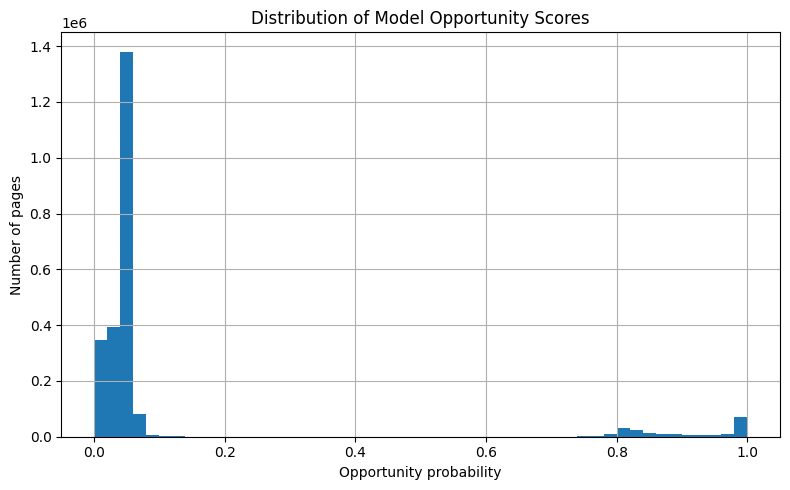

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

queue["opportunity_probability"].hist(bins=50)

plt.xlabel("Opportunity probability")
plt.ylabel("Number of pages")
plt.title("Distribution of Model Opportunity Scores")
plt.tight_layout()
plt.show()

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Exports for the paper

The notebook exports the ranked review queue so that the paper can use the same
output described in this analysis. The queue contains the priority rank,
opportunity probability, action, reason code, archetype, and supporting signals.

The queue is regenerated by the notebook rather than committed as a data file.
This keeps the repository free of large data outputs while preserving a
reproducible process.

The score-distribution figure is also saved for possible reuse in the paper.

In [50]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Save the final ranked queue

from pathlib import Path

output_dir = Path("work/outputs")
figure_dir = Path("work/figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

queue_path = output_dir / "refresh_queue_sample.csv"

queue_export.head(1000).to_csv(
    queue_path,
    index=False
)

print("Queue saved to:", queue_path)
print("Rows:", len(queue_export.head(1000)))

Queue saved to: work/outputs/refresh_queue_sample.csv
Rows: 1000


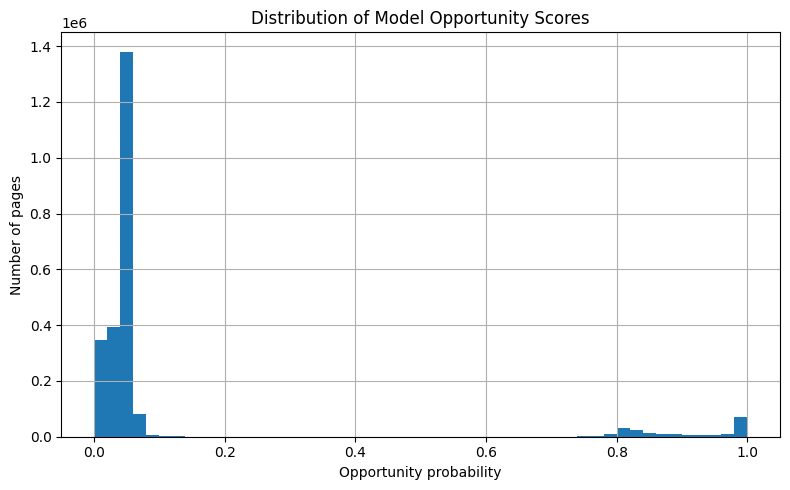

Figure saved to: work/figures/opportunity_score_distribution.png


In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

queue["opportunity_probability"].hist(bins=50)

plt.xlabel("Opportunity probability")
plt.ylabel("Number of pages")
plt.title("Distribution of Model Opportunity Scores")
plt.tight_layout()

figure_path = figure_dir / "opportunity_score_distribution.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")

plt.show()

print("Figure saved to:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Self-check

- [x] Intended use is clearly stated as decision support and prioritization.
- [x] Ranked actions and reason codes are included.
- [x] Archetype → action mapping is included.
- [x] Human review is required before content changes.
- [x] No-go cases are explicitly stated.
- [x] Monitoring and retrain triggers are documented.
- [x] The ranked queue is exported to `work/outputs/refresh_queue_sample.csv`.
- [x] The score-distribution figure is exported to `work/figures/opportunity_score_distribution.png`.
- [x] Claims are limited to what the validation supports.
- [x] The model is not presented as causal or as an autonomous production system.
- [ ] The complete notebook has been run from top to bottom without errors.
- [ ] The executed notebook has been committed to the repository.

In [52]:
# Final W07 output check

from pathlib import Path

queue_path = Path("work/outputs/refresh_queue_sample.csv")
figure_path = Path("work/figures/opportunity_score_distribution.png")

print("W07 ACTION PLAYBOOK — FINAL CHECK")
print("----------------------------------")

print("Queue exists:", queue_path.exists())
print("Figure exists:", figure_path.exists())

if queue_path.exists():
    exported_queue = pd.read_csv(queue_path)
    print("Queue rows:", len(exported_queue))
    print("Queue columns:", exported_queue.columns.tolist())

print("\nW07 notebook outputs are ready.")

W07 ACTION PLAYBOOK — FINAL CHECK
----------------------------------
Queue exists: True
Figure exists: True
Queue rows: 1000
Queue columns: ['priority_rank', 'opportunity_probability', 'recommended_action', 'reason_code', 'review_note', 'baseline_score', 'ctr_90d', 'ctr_last30', 'ctr_prev30', 'avg_position_90d', 'avg_position_last30', 'impressions_90d', 'clicks_90d', 'archetype', 'review_action', 'review_status']

W07 notebook outputs are ready.
